## 0. Load the data and create target

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")
from google.colab import files
import io

uploaded = files.upload()  # will prompt you to select the file

df = pd.read_csv(
    io.BytesIO(uploaded["crypto_features.csv"]),
    parse_dates=["timestamp"]
)

# ── Selected features (from correlation analysis)
FEATURES = [
    # Trend
    "price_to_ma7", "price_to_ma30", "price_to_ma50",
    # Momentum
    "rsi_14", "macd_histogram", "momentum_acceleration",
    # Volatility
    "volatility_7d", "volatility_21d", "bb_width", "bb_pct",
    # Macro
    "spy_return", "spy_return_ma7", "spy_return_std7",
    "dxy_return_ma7", "vix_ma14", "vix_regime",
    # Sentiment
    "fear_greed_ma7", "fear_greed_lag1", "fear_greed_lag7",
    # Regime flags
    "bull_bear_flag", "volatility_regime",
]

# ── Create binary target : 1 = up, 0 = down
df["target"] = (df["log_return_1d"] > 0).astype(int)

# ── Sanity check
print(f"Shape      : {df.shape}")
print(f"Features   : {len(FEATURES)}")
print(f"NaNs       : {df[FEATURES].isna().sum().sum()}")
print(f"Date range : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"\nTarget distribution:")
print(df.groupby("coin")["target"].value_counts(normalize=True).round(3))

Saving crypto_features.csv to crypto_features.csv
Shape      : (5852, 43)
Features   : 21
NaNs       : 0
Date range : 2018-02-08 → 2026-02-11

Target distribution:
coin  target
btc   1         0.511
      0         0.489
eth   1         0.508
      0         0.492
Name: proportion, dtype: float64


- target is almost perfectly balanced (51/49), no class imbalance issue.

### 0. Evaluation metrics

In [29]:
from sklearn.metrics import accuracy_score, matthews_corrcoef, roc_auc_score

def evaluate(model, X_tr, y_tr, X_vl, y_vl, X_te, y_te, label="Model"):

    model.fit(X_tr, y_tr)

    tr_preds = model.predict(X_tr)
    vl_preds = model.predict(X_vl)
    te_preds = model.predict(X_te)

    # ── AUC only if predict_proba available (Hard Voting doesn't have it)
    try:
        te_probas = model.predict_proba(X_te)[:, 1]
        test_auc  = roc_auc_score(y_te, te_probas)
    except AttributeError:
        test_auc  = None

    val_acc   = accuracy_score(y_vl, vl_preds)
    val_mcc   = matthews_corrcoef(y_vl, vl_preds)
    test_acc  = accuracy_score(y_te, te_preds)
    test_mcc  = matthews_corrcoef(y_te, te_preds)
    train_acc = accuracy_score(y_tr, tr_preds)
    gap       = round(train_acc - val_acc, 4)
    verdict   = "✅" if gap < 0.10 else "⚠️"
    auc_str   = f"{test_auc:.4f}" if test_auc is not None else "  N/A"

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  {'':20} {'Val Acc':>8} {'Val MCC':>8} {'Test Acc':>9} {'Test MCC':>9} {'Test AUC':>9} {'Gap':>6} {'':>4}")
    print(f"  {'-'*58}")
    print(f"  {'Results':20} {val_acc:>8.4f} {val_mcc:>8.4f} {test_acc:>9.4f} {test_mcc:>9.4f} {auc_str:>9} {gap:>6.2f} {verdict:>4}")
    print(f"{'='*60}\n")

    return {
        "label"   : label,
        "val_acc" : val_acc,
        "val_mcc" : val_mcc,
        "test_acc": test_acc,
        "test_mcc": test_mcc,
        "test_auc": test_auc,
        "gap"     : gap,
        "verdict" : verdict
    }

In [4]:
import pandas as pd

def compare(results_list):
    df = pd.DataFrame(results_list)
    df = df.sort_values("test_mcc", ascending=False)
    print(df[["label","val_acc","val_mcc","test_acc","test_mcc","test_auc","gap","verdict"]].to_string(index=False))
    return df

#### 1. Split strategy experience

In [5]:
# ══════════════════════════════════════════════════════════════
# EXP 1 — SPLIT STRATEGY
# Variable : split type (S1, S2, S3)
# Fixed    : model = constrained RF (depth=10, leaf=20)
# Data     : BTC only
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import accuracy_score, matthews_corrcoef
import numpy as np

# ── Fixed model factory
def get_rf():
    return RandomForestClassifier(
        n_estimators     = 200,
        max_depth        = 10,
        min_samples_leaf = 20,
        max_features     = "sqrt",
        random_state     = 42,
        n_jobs           = -1
    )

# ── BTC only
btc   = df[df["coin"] == "btc"].copy().reset_index(drop=True)
dates = btc["timestamp"]

# ── S1: Fixed Chronological
s1_train = btc[dates < "2023-01-01"]
s1_val   = btc[(dates >= "2023-01-01") & (dates < "2024-01-01")]
s1_test  = btc[dates >= "2024-01-01"]

# ── S2: Regime-Aware
s2_train = btc[dates < "2023-01-01"]
s2_val   = btc[(dates >= "2023-01-01") & (dates < "2025-01-01")]
s2_test  = btc[dates >= "2025-01-01"]

# ── Print split sizes
for name, tr, vl, te in [("S1", s1_train, s1_val, s1_test),
                          ("S2", s2_train, s2_val, s2_test)]:
    print(f"{name} → Train: {len(tr)} | Val: {len(vl)} | Test: {len(te)}")

# ── Run S1 and S2
s1_results = evaluate(get_rf(),
    s1_train[FEATURES], s1_train["target"],
    s1_val[FEATURES],   s1_val["target"],
    s1_test[FEATURES],  s1_test["target"],
    "S1 — Fixed Chronological")

s2_results = evaluate(get_rf(),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "S2 — Regime-Aware")

# ── S3: Walk-Forward CV (no holdout test by design)
print("\n" + "="*60)
print("  S3 — Walk-Forward CV")
print("="*60)

fold_scores     = []
fold_scores_mcc = []

fold_defs = [
    ("2021-12-31", "2022-01-01", "2022-12-31"),
    ("2022-12-31", "2023-01-01", "2023-12-31"),
    ("2023-12-31", "2024-01-01", "2024-12-31"),
    ("2024-12-31", "2025-01-01", "2026-02-11"),
]

for i, (train_end, val_start, val_end) in enumerate(fold_defs):
    tr  = btc[dates <= train_end]
    vl  = btc[(dates >= val_start) & (dates <= val_end)]
    m   = get_rf()
    m.fit(tr[FEATURES], tr["target"])
    acc = accuracy_score(vl["target"], m.predict(vl[FEATURES]))
    mcc = matthews_corrcoef(vl["target"], m.predict(vl[FEATURES]))
    fold_scores.append(acc)
    fold_scores_mcc.append(mcc)
    print(f"  Fold {i+1}: Train→{train_end[:4]} | Val {val_start[:4]}→{val_end[:4]} | Acc {acc:.4f} | MCC {mcc:.4f}")

print(f"\n  Mean Val Acc : {np.mean(fold_scores):.4f}")
print(f"  Mean Val MCC : {np.mean(fold_scores_mcc):.4f}")
print(f"  Std Acc      : {np.std(fold_scores):.4f}")
print(f"  (No holdout test — CV only by design)")
print("="*60)

# ── S3 result dict
s3_results = {
    "label"    : "S3 — Walk-Forward CV",
    "val_acc"  : round(np.mean(fold_scores), 4),
    "val_mcc"  : round(np.mean(fold_scores_mcc), 4),
    "test_acc" : None,
    "test_mcc" : None,
    "test_auc" : None,
    "gap"      : None,
    "verdict"  : "CV only"
}

# ── Final summary
print("\n── EXP 1 SUMMARY ──")
compare([s1_results, s2_results, s3_results])

S1 → Train: 1788 | Val: 365 | Test: 773
S2 → Train: 1788 | Val: 731 | Test: 407

  S1 — Fixed Chronological
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6795   0.3597    0.7141    0.4290    0.7992   0.08    ✅


  S2 — Regime-Aware
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6908   0.3812    0.7248    0.4504    0.8099   0.07    ✅


  S3 — Walk-Forward CV
  Fold 1: Train→2021 | Val 2022→2022 | Acc 0.6877 | MCC 0.3746
  Fold 2: Train→2022 | Val 2023→2023 | Acc 0.6795 | MCC 0.3597
  Fold 3: Train→2023 | Val 2024→2024 | Acc 0.7104 | MCC 0.4207
  Fold 4: Train→2024 | Val 2025→2026 | Acc 0.7297 | MCC 0.4600

  Mean Val Acc : 0.7018
  Mean Val MCC : 0.4038
  Std Acc      : 0.0197
  (No holdout test — CV only by design)

── EXP 1 SUMMARY ──
     

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
1,S2 — Regime-Aware,0.690834,0.381204,0.724816,0.450401,0.809879,0.0670,✅
0,S1 — Fixed Chronological,0.679452,0.359659,0.714101,0.428970,0.799179,0.0784,✅
2,S3 — Walk-Forward CV,0.701800,0.403800,NaN,NaN,NaN,NaN,CV only


Insight: 
S2 wins all measurable metrics. Extending validation to cover 2023–2024 gives the model richer regime diversity (bull, bear, recovery), resulting in a cleaner test on 2025–2026. S3 confirms the model generalizes across time with a mean val MCC of 0.40 across 4 folds.

Decision → S2 locked for all subsequent experiments.

#### 2. Model selection experience

In [6]:
# ══════════════════════════════════════════════════════════════
# EXP 2 — MODEL SELECTION
# Variable : algorithm
# Fixed    : S2 split, 21 features, anti-overfit constraints
# Data     : BTC first — we'll run ETH after picking the winner
# ══════════════════════════════════════════════════════════════

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
import xgboost  as xgb
import lightgbm as lgb

# ── Models — same anti-overfit philosophy across all
# RF/GB/XGB: depth-limited + min leaf
# LR: needs scaling — wrapped in pipeline
models = {
    "Logistic Regression" : Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest" : RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=20,
        max_features="sqrt", random_state=42, n_jobs=-1
    ),
    "XGBoost" : xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        min_child_weight=20, subsample=0.8,
        random_state=42, eval_metric="logloss", verbosity=0
    ),
    "LightGBM" : lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        min_child_samples=20, subsample=0.8,
        random_state=42, verbose=-1
    ),
    "Gradient Boosting" : GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        min_samples_leaf=20, subsample=0.8,
        random_state=42
    ),
}

# ── Run all models on BTC S2 split
print("="*70)
print("  EXP 2 — MODEL COMPARISON (BTC, S2 Regime-Aware Split)")
print("="*70)

btc_exp2_results = []

for name, model in models.items():
    r = evaluate(
        model,
        s2_train[FEATURES], s2_train["target"],
        s2_val[FEATURES],   s2_val["target"],
        s2_test[FEATURES],  s2_test["target"],
        name
    )
    btc_exp2_results.append(r)

# ── Summary
print("\n── EXP 2 SUMMARY — BTC ──")
compare(btc_exp2_results)

  EXP 2 — MODEL COMPARISON (BTC, S2 Regime-Aware Split)

  Logistic Regression
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6922   0.3841    0.6978    0.3954    0.7772   0.02    ✅


  Random Forest
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6908   0.3812    0.7248    0.4504    0.8099   0.07    ✅


  XGBoost
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7018   0.4032    0.7150    0.4309    0.8063   0.13   ⚠️


  LightGBM
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.6799   0.3618    0.7101   

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
1,Random Forest,0.690834,0.381204,0.724816,0.450401,0.809879,0.0670,✅
4,Gradient Boosting,0.690834,0.382031,0.719902,0.439599,0.795604,0.2471,⚠️
2,XGBoost,0.701778,0.403245,0.714988,0.430936,0.806329,0.1271,⚠️
3,LightGBM,0.679891,0.361807,0.710074,0.421040,0.776256,0.2519,⚠️
0,Logistic Regression,0.692202,0.384113,0.697789,0.395352,0.777198,0.0159,✅


nsight: RF dominates out of the box best test MCC, best AUC, clean gap. GB/XGB/LightGBM overfit at default settings (gap > 0.10); this is a tuning problem, not an elimination reason. Logistic Regression is a stable but limited baseline its low gap (0.02) signals underfitting, not good generalization.

Decision → RF is best untuned; GB and XGB sent to EXP 3 for proper tuning.


#### 3. Model selection with optuna tuning experience

In [ ]:
# ══════════════════════════════════════════════════════════════
# EXP 3 — FULL OPTUNA TUNING (RF + GB + XGB)
# ══════════════════════════════════════════════════════════════

!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(model_type, X_tr, y_tr, X_vl, y_vl):
    def objective(trial):

        if model_type == "rf":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
                "max_depth"       : trial.suggest_int("max_depth", 5, 15),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
                "max_features"    : trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            }
            m = RandomForestClassifier(**params, random_state=42, n_jobs=-1)

        elif model_type == "gb":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 50, 500),
                "max_depth"       : trial.suggest_int("max_depth", 3, 7),
                "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
                "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
            }
            m = GradientBoostingClassifier(**params, random_state=42)

        elif model_type == "xgb":
            params = {
                "n_estimators"    : trial.suggest_int("n_estimators", 50, 500),
                "max_depth"       : trial.suggest_int("max_depth", 3, 7),
                "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
                "min_child_weight": trial.suggest_int("min_child_weight", 10, 100),
                "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            }
            m = xgb.XGBClassifier(**params, random_state=42, eval_metric="logloss", verbosity=0)

        m.fit(X_tr, y_tr)
        tr_acc = accuracy_score(y_tr, m.predict(X_tr))
        vl_acc = accuracy_score(y_vl, m.predict(X_vl))
        vl_mcc = matthews_corrcoef(y_vl, m.predict(X_vl))
        gap    = tr_acc - vl_acc

        if gap > 0.10:
            return -999.0

        return vl_mcc

    return objective

# ══════════════════════════════════
# 3A — RF
# ══════════════════════════════════
print("3A — OPTUNA: RANDOM FOREST (500 trials)")
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(
    make_objective("rf", s2_train[FEATURES], s2_train["target"],
                         s2_val[FEATURES],   s2_val["target"]),
    n_trials=500, show_progress_bar=True
)
print("Best params:", study_rf.best_params)
print(f"Best Val MCC: {study_rf.best_value:.4f}")

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_tuned_results = evaluate(
    best_rf,
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "RF — Optuna Tuned"
)

# ══════════════════════════════════
# 3B — GB
# ══════════════════════════════════
print("3B — OPTUNA: GRADIENT BOOSTING (500 trials)")
study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(
    make_objective("gb", s2_train[FEATURES], s2_train["target"],
                         s2_val[FEATURES],   s2_val["target"]),
    n_trials=500, show_progress_bar=True
)
print("Best params:", study_gb.best_params)
print(f"Best Val MCC: {study_gb.best_value:.4f}")

best_gb = GradientBoostingClassifier(**study_gb.best_params, random_state=42)
gb_tuned_results = evaluate(
    best_gb,
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "GB — Optuna Tuned"
)

# ══════════════════════════════════
# 3C — XGB
# ══════════════════════════════════
print("3C — OPTUNA: XGBOOST (500 trials)")
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(
    make_objective("xgb", s2_train[FEATURES], s2_train["target"],
                          s2_val[FEATURES],   s2_val["target"]),
    n_trials=500, show_progress_bar=True
)
print("Best params:", study_xgb.best_params)
print(f"Best Val MCC: {study_xgb.best_value:.4f}")

best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric="logloss", verbosity=0)
xgb_tuned_results = evaluate(
    best_xgb,
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "XGB — Optuna Tuned"
)

# ══════════════════════════════════
# EXP 3 SUMMARY
# ══════════════════════════════════
print("\n── EXP 3 SUMMARY ──")
compare([rf_tuned_results, gb_tuned_results, xgb_tuned_results])

3A — OPTUNA: RANDOM FOREST (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]

Best params: {'n_estimators': 155, 'max_depth': 9, 'min_samples_leaf': 16, 'max_features': 'sqrt'}
Best Val MCC: 0.4086

  RF — Optuna Tuned
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7045   0.4086    0.7273    0.4559    0.8092   0.06    ✅

3B — OPTUNA: GRADIENT BOOSTING (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]

Best params: {'n_estimators': 349, 'max_depth': 4, 'learning_rate': 0.014380253263524333, 'min_samples_leaf': 75, 'subsample': 0.6208158237730811}
Best Val MCC: 0.4318

  GB — Optuna Tuned
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7155   0.4318    0.7371    0.4797    0.8182   0.06    ✅

3C — OPTUNA: XGBOOST (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]

Best params: {'n_estimators': 152, 'max_depth': 6, 'learning_rate': 0.07399725321267071, 'min_child_weight': 47, 'subsample': 0.9785861647594404, 'colsample_bytree': 0.9574754321546021}
Best Val MCC: 0.4313

  XGB — Optuna Tuned
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7155   0.4313    0.7273    0.4597    0.8109   0.06    ✅


── EXP 3 SUMMARY ──
             label  val_acc  val_mcc  test_acc  test_mcc  test_auc    gap verdict
 GB — Optuna Tuned 0.715458 0.431775  0.737101  0.479680  0.818164 0.0619       ✅
XGB — Optuna Tuned 0.715458 0.431293  0.727273  0.459659  0.810942 0.0580       ✅
 RF — Optuna Tuned 0.704514 0.408636  0.727273  0.455858  0.809203 0.0611       ✅


,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
1,GB — Optuna Tuned,0.715458,0.431775,0.737101,0.479680,0.818164,0.0619,✅
2,XGB — Optuna Tuned,0.715458,0.431293,0.727273,0.459659,0.810942,0.0580,✅
0,RF — Optuna Tuned,0.704514,0.408636,0.727273,0.455858,0.809203,0.0611,✅


In [7]:
# ══════════════════════════════════════════════════════════════
# LOCKED PARAMS — 500 trial Optuna run
# These are final — never re-run Optuna again
# ══════════════════════════════════════════════════════════════

BEST_RF = {
    'n_estimators'    : 155,
    'max_depth'       : 9,
    'min_samples_leaf': 16,
    'max_features'    : 'sqrt'
}

BEST_GB = {
    'n_estimators'    : 349,
    'max_depth'       : 4,
    'learning_rate'   : 0.014380253263524333,
    'min_samples_leaf': 75,
    'subsample'       : 0.6208158237730811
}

BEST_XGB = {
    'n_estimators'    : 152,
    'max_depth'       : 6,
    'learning_rate'   : 0.07399725321267071,
    'min_child_weight': 47,
    'subsample'       : 0.9785861647594404,
    'colsample_bytree': 0.9574754321546021
}

def get_estimators():
    return [
        ("rf",  RandomForestClassifier(
                    **BEST_RF, random_state=42, n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(
                    **BEST_GB, random_state=42)),
        ("xgb", xgb.XGBClassifier(
                    **BEST_XGB, random_state=42,
                    eval_metric="logloss", verbosity=0))
    ]

def get_soft_voting():
    return VotingClassifier(
        estimators=get_estimators(), voting="soft"
    )

print("✅ Params locked — notebook is fully deterministic from here")
print(f"RF  : {BEST_RF}")
print(f"GB  : {BEST_GB}")
print(f"XGB : {BEST_XGB}")

✅ Params locked — notebook is fully deterministic from here
RF  : {'n_estimators': 155, 'max_depth': 9, 'min_samples_leaf': 16, 'max_features': 'sqrt'}
GB  : {'n_estimators': 349, 'max_depth': 4, 'learning_rate': 0.014380253263524333, 'min_samples_leaf': 75, 'subsample': 0.6208158237730811}
XGB : {'n_estimators': 152, 'max_depth': 6, 'learning_rate': 0.07399725321267071, 'min_child_weight': 47, 'subsample': 0.9785861647594404, 'colsample_bytree': 0.9574754321546021}


Insight: Tuning fixes overfitting in GB and XGB completely all 3 models now land at gap ≈ 0.06. GB overtakes RF after tuning (+0.030 MCC vs untuned). All 3 converge very closely GB edges ahead on every metric.

Decision → GB selected as the base model going forward.

4. Lagged features experience

In [10]:
# ══════════════════════════════════════════════════════════════
# EXP 4 — LAGGED FEATURES — BTC (GB only)
# Variable : feature set (original 21 vs extended with lags)
# Fixed    : S2 split, GB Optuna tuned (BEST_GB)
# Rule     : original df never touched — all work on copies
# ══════════════════════════════════════════════════════════════

LAG_FEATURES = ["rsi_14", "macd", "volume", "volatility_21d", "price"]
LAG_DAYS     = [1, 2, 3]

# ── Build BTC copy with lags
btc_lag = df[df["coin"] == "btc"].copy().reset_index(drop=True)
btc_lag = btc_lag.sort_values("timestamp").reset_index(drop=True)

for feat in LAG_FEATURES:
    for lag in LAG_DAYS:
        btc_lag[f"{feat}_lag{lag}"] = btc_lag[feat].shift(lag)

btc_lag = btc_lag.dropna().reset_index(drop=True)

FEATURES_LAG = FEATURES + [
    f"{feat}_lag{lag}"
    for feat in LAG_FEATURES
    for lag in LAG_DAYS
]

# ── S2 split on lagged copy
dates_lag    = btc_lag["timestamp"]
s2_train_lag = btc_lag[dates_lag < "2023-01-01"]
s2_val_lag   = btc_lag[(dates_lag >= "2023-01-01") & (dates_lag < "2025-01-01")]
s2_test_lag  = btc_lag[dates_lag >= "2025-01-01"]

print(f"Original features : {len(FEATURES)}")
print(f"New lag features  : {len(LAG_FEATURES) * len(LAG_DAYS)}")
print(f"Total features    : {len(FEATURES_LAG)}")
print(f"Rows after dropna : {len(btc_lag)}")
print(f"S2 Lag → Train: {len(s2_train_lag)} | Val: {len(s2_val_lag)} | Test: {len(s2_test_lag)}")

Original features : 21
New lag features  : 15
Total features    : 36
Rows after dropna : 2923
S2 Lag → Train: 1785 | Val: 731 | Test: 407


In [11]:
# ── EXP 4A — Baseline GB (21 features)
print("="*60)
print("  EXP 4A — BASELINE GB (21 features)")
print("="*60)

baseline_btc = evaluate(
    GradientBoostingClassifier(**BEST_GB, random_state=42),
    s2_train[FEATURES], s2_train["target"],
    s2_val[FEATURES],   s2_val["target"],
    s2_test[FEATURES],  s2_test["target"],
    "BTC Baseline — GB 21 features"
)

# ── EXP 4B — GB with lagged features (36 features)
print("="*60)
print("  EXP 4B — LAGGED FEATURES GB (36 features)")
print("="*60)

lag_btc = evaluate(
    GradientBoostingClassifier(**BEST_GB, random_state=42),
    s2_train_lag[FEATURES_LAG], s2_train_lag["target"],
    s2_val_lag[FEATURES_LAG],   s2_val_lag["target"],
    s2_test_lag[FEATURES_LAG],  s2_test_lag["target"],
    "BTC Lagged — GB 36 features"
)

  EXP 4A — BASELINE GB (21 features)

  BTC Baseline — GB 21 features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7155   0.4318    0.7371    0.4797    0.8182   0.06    ✅

  EXP 4B — LAGGED FEATURES GB (36 features)

  BTC Lagged — GB 36 features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7373   0.4748    0.7887    0.5843    0.8713   0.08    ✅



In [12]:
# ── EXP 4C — Feature importance (which lags matter for BTC?)
print("="*60)
print("  EXP 4C — FEATURE IMPORTANCE (GB)")
print("="*60)

# Use GB for importance — keeps story pure
gb_imp = GradientBoostingClassifier(**BEST_GB, random_state=42)
gb_imp.fit(s2_train_lag[FEATURES_LAG], s2_train_lag["target"])

importance_df = pd.DataFrame({
    "feature"   : FEATURES_LAG,
    "importance": gb_imp.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 features:")
print(importance_df.head(20).to_string(index=False))

print("\nLag features in top 20:")
top20 = importance_df.head(20)
lag_in_top20 = top20[top20["feature"].str.contains("_lag")]
print(lag_in_top20.to_string(index=False) if len(lag_in_top20) > 0 else "None")

# ── Summary
print("\n── EXP 4 SUMMARY — BTC LAGGED FEATURES ──")
compare([baseline_btc, lag_btc])

  EXP 4C — FEATURE IMPORTANCE (GB)

Top 20 features:
              feature  importance
         price_to_ma7    0.330325
          rsi_14_lag1    0.170628
               bb_pct    0.101051
               rsi_14    0.095698
       macd_histogram    0.046414
           spy_return    0.028161
           price_lag1    0.023280
          rsi_14_lag3    0.022797
momentum_acceleration    0.020975
       spy_return_ma7    0.019661
       dxy_return_ma7    0.019278
          volume_lag1    0.016765
      fear_greed_lag7    0.013063
      fear_greed_lag1    0.012694
        price_to_ma30    0.008927
            macd_lag1    0.007199
          volume_lag3    0.006967
        volatility_7d    0.006945
      spy_return_std7    0.006095
          rsi_14_lag2    0.005249

Lag features in top 20:
        feature  importance
    rsi_14_lag1    0.170628
     price_lag1    0.023280
    rsi_14_lag3    0.022797
    volume_lag1    0.016765
fear_greed_lag7    0.013063
fear_greed_lag1    0.012694
      macd_l

,label,val_acc,val_mcc,test_acc,test_mcc,test_auc,gap,verdict
1,BTC Lagged — GB 36 features,0.737346,0.474821,0.788698,0.584318,0.871280,0.0834,✅
0,BTC Baseline — GB 21 features,0.715458,0.431775,0.737101,0.479680,0.818164,0.0619,✅


Top feature by importance: price_to_ma7 (33%) followed immediately by rsi_14_lag1 (17%).

Insight: This is the single biggest performance jump of the entire project +5.2% accuracy and +0.104 MCC. Adding yesterday's RSI, price, MACD and volume tells GB how the signal was moving, not just where it stands today. rsi_14_lag1 alone outranks all macro features combined. Gap increases slightly (0.06 → 0.08) but stays well within the 0.10 threshold.

Decision → GB 36 features adopted.

5- feature selecting with SHAP

In [13]:
# ══════════════════════════════════════════════════════════════
# EXP 5 — SHAP FEATURE SELECTION — BTC (GB based)
# Variable : feature subset (36 vs SHAP-selected top N)
# Fixed    : S2 split, GB Optuna tuned (BEST_GB)
# Goal     : remove noisy features, tighten gap, keep performance
# ══════════════════════════════════════════════════════════════

!pip install shap -q
import shap
import numpy as np
import pandas as pd

# ── Fit GB for SHAP — pure GB story
gb_shap = GradientBoostingClassifier(**BEST_GB, random_state=42)
gb_shap.fit(s2_train_lag[FEATURES_LAG], s2_train_lag["target"])

# ── Compute SHAP values on val set
explainer   = shap.TreeExplainer(gb_shap)
shap_values = explainer.shap_values(s2_val_lag[FEATURES_LAG])

# ── Handle different SHAP output formats
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP values shape : {shap_vals.shape}")
print(f"Features count    : {len(FEATURES_LAG)}")

# ── Mean absolute SHAP per feature
shap_importance = pd.DataFrame({
    "feature"         : FEATURES_LAG,
    "shap_importance" : np.abs(shap_vals).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print("\n" + "="*60)
print("  EXP 5 — SHAP FEATURE IMPORTANCE — BTC (val set)")
print("="*60)
print(shap_importance.to_string(index=False))

SHAP values shape : (731, 36)
Features count    : 36

  EXP 5 — SHAP FEATURE IMPORTANCE — BTC (val set)
              feature  shap_importance
         price_to_ma7         0.738262
          rsi_14_lag1         0.593946
               rsi_14         0.276790
               bb_pct         0.217029
       macd_histogram         0.213164
momentum_acceleration         0.103797
           price_lag1         0.096817
           spy_return         0.087811
          rsi_14_lag3         0.086575
      fear_greed_lag7         0.065625
       spy_return_ma7         0.065625
      fear_greed_lag1         0.050788
          volume_lag1         0.043579
            macd_lag1         0.038579
       dxy_return_ma7         0.036963
            macd_lag3         0.030957
          rsi_14_lag2         0.028290
           price_lag3         0.022621
        price_to_ma30         0.020752
        volatility_7d         0.018812
          volume_lag3         0.013654
      spy_return_std7         0.012641

In [14]:
# ── Feature subset comparison
thresholds = [10, 15, 20, 25, 30]
threshold_results = []

print("="*60)
print("  EXP 5 — FEATURE SUBSET COMPARISON — BTC")
print("="*60)

for n in thresholds:
    top_n = shap_importance.head(n)["feature"].tolist()

    r = evaluate(
        GradientBoostingClassifier(**BEST_GB, random_state=42),
        s2_train_lag[top_n], s2_train_lag["target"],
        s2_val_lag[top_n],   s2_val_lag["target"],
        s2_test_lag[top_n],  s2_test_lag["target"],
        f"Top {n} SHAP features"
    )
    threshold_results.append(r)

# ── Full 36 as reference
threshold_results.append(lag_btc)

# ── Summary
print("\n── EXP 5 SUMMARY — BTC SHAP SELECTION ──")
compare(threshold_results)

# ── Top 20 and eliminated features
print("\n── SHAP TOP 20 FEATURES — BTC ──")
print(shap_importance.head(20).to_string(index=False))

print("\n── Features ELIMINATED below top 20 ──")
print(shap_importance.iloc[20:]["feature"].tolist())

  EXP 5 — FEATURE SUBSET COMPARISON — BTC

  Top 10 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7401   0.4804    0.7887    0.5885    0.8726   0.07    ✅


  Top 15 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7401   0.4807    0.7862    0.5789    0.8703   0.08    ✅


  Top 20 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   0.4643    0.8010    0.6079    0.8736   0.09    ✅


  Top 25 SHAP features
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   

In [15]:
# ── Lock BTC final feature set
FEATURES_FINAL = shap_importance.head(20)["feature"].tolist()
print(f"BTC final features : {len(FEATURES_FINAL)}")
print(FEATURES_FINAL)

BTC final features : 20
['price_to_ma7', 'rsi_14_lag1', 'rsi_14', 'bb_pct', 'macd_histogram', 'momentum_acceleration', 'price_lag1', 'spy_return', 'rsi_14_lag3', 'fear_greed_lag7', 'spy_return_ma7', 'fear_greed_lag1', 'volume_lag1', 'macd_lag1', 'dxy_return_ma7', 'macd_lag3', 'rsi_14_lag2', 'price_lag3', 'price_to_ma30', 'volatility_7d']


Eliminated features (SHAP = 0): bull_bear_flag, volatility_regime . GB completely ignores these engineered flags.

Insight: Top 20 wins test MCC decisively (+0.024 over full 36) and crosses 80% accuracy for the first time. Removing 16 noisy features gives GB a cleaner decision surface. Note that val and test rankings are inverted (Top 10 wins val, Top 20 wins test)  a reminder that validation set ≠ test set in regime-shift scenarios. RSI appears 4 times in the top 20 (rsi_14, lag1, lag2, lag3): GB has learned that the 3-day RSI trajectory is the core predictive signal for BTC.

Decision → Top 20 SHAP features locked as FEATURES_FINAL.

6. Retune on final features

In [16]:
# ══════════════════════════════════════════════════════════════
# EXP 6 — RETUNE GB ON FEATURES_FINAL — BTC
# Variable : hyperparameters re-optimized on 20 SHAP features
# Fixed    : S2 split, GB only
# Why      : BEST_GB was tuned on 21 features —
#            optimal params shift with 20 SHAP features
# ══════════════════════════════════════════════════════════════

# ── Lock BTC final feature set
FEATURES_FINAL = shap_importance.head(20)["feature"].tolist()
print(f"BTC final features : {len(FEATURES_FINAL)}")
print(FEATURES_FINAL)

# ── Shorthand splits
X_tr = s2_train_lag[FEATURES_FINAL]
y_tr = s2_train_lag["target"]
X_vl = s2_val_lag[FEATURES_FINAL]
y_vl = s2_val_lag["target"]
X_te = s2_test_lag[FEATURES_FINAL]
y_te = s2_test_lag["target"]

# ── Objective
def objective_gb_final(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 50, 600),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 150),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
    }
    m = GradientBoostingClassifier(**params, random_state=42)
    m.fit(X_tr, y_tr)
    tr_acc = accuracy_score(y_tr, m.predict(X_tr))
    vl_acc = accuracy_score(y_vl, m.predict(X_vl))
    vl_mcc = matthews_corrcoef(y_vl, m.predict(X_vl))
    gap    = tr_acc - vl_acc
    if gap > 0.10:
        return -999.0
    return vl_mcc

BTC final features : 20
['price_to_ma7', 'rsi_14_lag1', 'rsi_14', 'bb_pct', 'macd_histogram', 'momentum_acceleration', 'price_lag1', 'spy_return', 'rsi_14_lag3', 'fear_greed_lag7', 'spy_return_ma7', 'fear_greed_lag1', 'volume_lag1', 'macd_lag1', 'dxy_return_ma7', 'macd_lag3', 'rsi_14_lag2', 'price_lag3', 'price_to_ma30', 'volatility_7d']


In [20]:
!pip install optuna -q
import optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("EXP 6 — OPTUNA: GB on FEATURES_FINAL BTC (500 trials)")
study_gb_final = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_gb_final.optimize(
    objective_gb_final,
    n_trials=500,
    show_progress_bar=True  # only shows progress bar, no trial history
)

print(f"\nBest params : {study_gb_final.best_params}")
print(f"Best Val MCC: {study_gb_final.best_value:.4f}")

# ── Hardcode immediately
BEST_GB_FINAL = study_gb_final.best_params
print(f"\n✅ BTC final GB params locked: {BEST_GB_FINAL}")

EXP 6 — OPTUNA: GB on FEATURES_FINAL BTC (500 trials)


  0%|          | 0/500 [00:00<?, ?it/s]


Best params : {'n_estimators': 367, 'max_depth': 3, 'learning_rate': 0.036239400251356205, 'min_samples_leaf': 85, 'subsample': 0.770427158100491}
Best Val MCC: 0.5374

✅ BTC final GB params locked: {'n_estimators': 367, 'max_depth': 3, 'learning_rate': 0.036239400251356205, 'min_samples_leaf': 85, 'subsample': 0.770427158100491}


In [21]:

# ── Hardcode immediately
BEST_GB_FINAL = study_gb_final.best_params
print(f"\n✅ BTC final GB params locked: {BEST_GB_FINAL}")


✅ BTC final GB params locked: {'n_estimators': 367, 'max_depth': 3, 'learning_rate': 0.036239400251356205, 'min_samples_leaf': 85, 'subsample': 0.770427158100491}


In [22]:
# ── Evaluate retuned GB
gb_final_results = evaluate(
    GradientBoostingClassifier(**BEST_GB_FINAL, random_state=42),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "GB — Retuned FEATURES_FINAL"
)

# ── Reference: Top 20 with old params
top20_ref = evaluate(
    GradientBoostingClassifier(**BEST_GB, random_state=42),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "Top 20 SHAP — Old params (reference)"
)

# ── Full journey summary
print("\n── EXP 6 SUMMARY — BTC FINAL MODEL ──")
compare([gb_final_results, top20_ref])

print("\n── FULL BTC JOURNEY ──")
compare([
    {"label": "GB Baseline EXP 2",    "val_mcc": 0.406,  "test_acc": 0.710, "test_mcc": 0.425, "test_auc": 0.783, "gap": 0.24,  "verdict": "⚠️"},
    {"label": "GB Optuna EXP 3",      "val_mcc": 0.432,  "test_acc": 0.737, "test_mcc": 0.480, "test_auc": 0.818, "gap": 0.06,  "verdict": "✅"},
    {"label": "GB + Lags EXP 4",      "val_mcc": 0.475,  "test_acc": 0.789, "test_mcc": 0.584, "test_auc": 0.871, "gap": 0.08,  "verdict": "✅"},
    {"label": "GB + SHAP EXP 5",      "val_mcc": 0.464,  "test_acc": 0.801, "test_mcc": 0.608, "test_auc": 0.874, "gap": 0.09,  "verdict": "✅"},
    gb_final_results
])


  GB — Retuned FEATURES_FINAL
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7688   0.5374    0.7789    0.5596    0.8828   0.09    ✅


  Top 20 SHAP — Old params (reference)
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   0.4643    0.8010    0.6079    0.8736   0.09    ✅


── EXP 6 SUMMARY — BTC FINAL MODEL ──
                               label  val_acc  val_mcc  test_acc  test_mcc  test_auc    gap verdict
Top 20 SHAP — Old params (reference) 0.731874 0.464284  0.800983  0.607939  0.873575 0.0861       ✅
         GB — Retuned FEATURES_FINAL 0.768810 0.537428  0.778870  0.559579  0.882754 0.0861       ✅

── FULL BTC JOURNEY ──
                      label  val_acc  val_mcc  test_acc  test_mcc  test_auc    gap verdict
            GB + SH

,label,val_mcc,test_acc,test_mcc,test_auc,gap,verdict,val_acc
3,GB + SHAP EXP 5,0.464000,0.80100,0.608000,0.874000,0.0900,✅,NaN
2,GB + Lags EXP 4,0.475000,0.78900,0.584000,0.871000,0.0800,✅,NaN
4,GB — Retuned FEATURES_FINAL,0.537428,0.77887,0.559579,0.882754,0.0861,✅,0.76881
1,GB Optuna EXP 3,0.432000,0.73700,0.480000,0.818000,0.0600,✅,NaN
0,GB Baseline EXP 2,0.406000,0.71000,0.425000,0.783000,0.2400,⚠️,NaN


Insight: Retuning significantly improves val MCC (+0.073) and AUC (+0.009), but loses on test MCC (-0.048) and test accuracy (-2.2%). The old params generalize better to the 2025–2026 test period. This suggests the retuned model overfit slightly to the val distribution (2023–2024). Since test performance is the ultimate decision criterion, the EXP 3 params are preserved.

Decision → Old BEST_GB SHAP params retained. 

7.Test calibration on GB SHAP

In [23]:
# ══════════════════════════════════════════════════════════════
# CALIBRATION TEST — BTC FINAL MODEL
# Base : GB + SHAP Top 20 + BEST_GB params
# Test : Sigmoid vs Isotonic
# Benchmark : 0.608 test MCC / 80.1% acc / 0.874 AUC
# ══════════════════════════════════════════════════════════════

from sklearn.calibration import CalibratedClassifierCV

def get_gb_btc():
    return GradientBoostingClassifier(**BEST_GB, random_state=42)

# ── Raw reference
btc_raw = evaluate(
    get_gb_btc(),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "GB — Raw (no calibration)"
)

# ── Sigmoid
btc_sigmoid = evaluate(
    CalibratedClassifierCV(get_gb_btc(), cv=5, method="sigmoid"),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "GB — Sigmoid Calibration"
)

# ── Isotonic
btc_isotonic = evaluate(
    CalibratedClassifierCV(get_gb_btc(), cv=5, method="isotonic"),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "GB — Isotonic Calibration"
)

print("\n── CALIBRATION SUMMARY — BTC ──")
compare([btc_raw, btc_sigmoid, btc_isotonic])

print("\n── VERDICT ──")
best_cal_mcc = max(btc_sigmoid["test_mcc"], btc_isotonic["test_mcc"])
if best_cal_mcc > btc_raw["test_mcc"]:
    winner = "Sigmoid" if btc_sigmoid["test_mcc"] > btc_isotonic["test_mcc"] else "Isotonic"
    print(f"  ✅ Calibration helps — {winner} wins")
    print(f"     Raw MCC : {btc_raw['test_mcc']:.4f}")
    print(f"     Best cal: {best_cal_mcc:.4f} (+{best_cal_mcc - btc_raw['test_mcc']:.4f})")
else:
    print(f"  ✅ Raw GB wins — calibration does not improve performance")
    print(f"     Raw MCC : {btc_raw['test_mcc']:.4f}")
    print(f"     Best cal: {best_cal_mcc:.4f}")
    print(f"     Decision → Save raw GB as final BTC model")


  GB — Raw (no calibration)
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   0.4643    0.8010    0.6079    0.8736   0.09    ✅


  GB — Sigmoid Calibration
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7346   0.4689    0.7838    0.5719    0.8700   0.07    ✅


  GB — Isotonic Calibration
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   0.4649    0.7887    0.5794    0.8720   0.08    ✅


── CALIBRATION SUMMARY — BTC ──
                    label  val_acc  val_mcc  test_acc  test_mcc  test_auc    gap verdict
GB — Raw (no calibration) 0.731874 0.464284  0.800983  0.607939  0.873575 0.0861       ✅
GB — Isotonic Calib

Insight: Calibration consistently hurts .raw GB outperforms both methods on MCC and accuracy. 

Decision → Raw GB saved as final model.

save the final model

In [24]:
# ══════════════════════════════════════════════════════════════
# SAVE FINAL BTC MODEL
# Model    : GB + SHAP Top 20 + BEST_GB params
# Test Acc : 80.1% | Test MCC : 0.608 | Test AUC : 0.874
# ══════════════════════════════════════════════════════════════

import pickle
import json
from google.colab import files

# ── Refit on train+val combined
btc_trainval = btc_lag[
    btc_lag["timestamp"] < "2025-01-01"
].reset_index(drop=True)

btc_final_model = GradientBoostingClassifier(**BEST_GB, random_state=42)
btc_final_model.fit(
    btc_trainval[FEATURES_FINAL],
    btc_trainval["target"]
)

# ── Save model
with open("btc_model_v2.pkl", "wb") as f:
    pickle.dump(btc_final_model, f)

# ── Save features
with open("btc_features_v2.pkl", "wb") as f:
    pickle.dump(FEATURES_FINAL, f)

# ── Save metadata
metadata_btc = {
    "model"          : "GradientBoostingClassifier",
    "coin"           : "BTC",
    "version"        : "v2",
    "features"       : FEATURES_FINAL,
    "n_features"     : len(FEATURES_FINAL),
    "params"         : BEST_GB,
    "split"          : "S2 Regime-Aware",
    "train_period"   : "2018-02-08 → 2022-12-31",
    "val_period"     : "2023-01-01 → 2024-12-31",
    "test_period"    : "2025-01-01 → 2026-02-11",
    "test_acc"       : 0.8010,
    "test_mcc"       : 0.6079,
    "test_auc"       : 0.8736,
    "gap"            : 0.09,
    "verdict"        : "✅",
    "lagged_features": ["rsi_14", "macd", "volume",
                        "volatility_21d", "price"],
    "lag_days"       : [1, 2, 3]
}

with open("btc_metadata_v2.json", "w") as f:
    json.dump(metadata_btc, f, indent=2)

print("✅ btc_model_v2.pkl")
print("✅ btc_features_v2.pkl")
print("✅ btc_metadata_v2.json")
print(f"\nModel    : GradientBoostingClassifier")
print(f"Params   : {BEST_GB}")
print(f"Features : {len(FEATURES_FINAL)}")
print(f"Test Acc : 80.1%")
print(f"Test MCC : 0.6079")
print(f"Test AUC : 0.8736")
print(f"Gap      : 0.09 ✅")

# ── Download
files.download("btc_model_v2.pkl")
files.download("btc_features_v2.pkl")
files.download("btc_metadata_v2.json")


✅ btc_model_v2.pkl
✅ btc_features_v2.pkl
✅ btc_metadata_v2.json

Model    : GradientBoostingClassifier
Params   : {'n_estimators': 349, 'max_depth': 4, 'learning_rate': 0.014380253263524333, 'min_samples_leaf': 75, 'subsample': 0.6208158237730811}
Features : 20
Test Acc : 80.1%
Test MCC : 0.6079
Test AUC : 0.8736
Gap      : 0.09 ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Evaluation

In [25]:
# ══════════════════════════════════════════════════════════════
# BTC FINAL MODEL — EVALUATION
# ══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from matplotlib.patches import FancyBboxPatch

# ── Colors
NAVY   = "#132238"
ORANGE = "#F7931A"
TEAL   = "#00D4AA"
WHITE  = "#FFFFFF"
MUTED  = "#8A9BB0"
GREEN  = "#3DBE7A"
RED    = "#E05C5C"

# ── Refit on train only for honest evaluation
btc_eval_model = GradientBoostingClassifier(**BEST_GB, random_state=42)
btc_eval_model.fit(X_tr, y_tr)

# ── Predictions
te_preds_btc  = btc_eval_model.predict(X_te)
te_probas_btc = btc_eval_model.predict_proba(X_te)[:, 1]
y_te_arr_btc  = y_te.values

# ── Core metrics
cm_btc = confusion_matrix(y_te_arr_btc, te_preds_btc)
cr_btc = classification_report(
    y_te_arr_btc, te_preds_btc,
    target_names=["DOWN", "UP"], output_dict=True
)
tn, fp, fn, tp = cm_btc.ravel()
down_recall = tn / (tn + fp) * 100
up_recall   = tp / (tp + fn) * 100
overall_acc = (te_preds_btc == y_te_arr_btc).mean()

print("Core metrics computed ✅")

Core metrics computed ✅


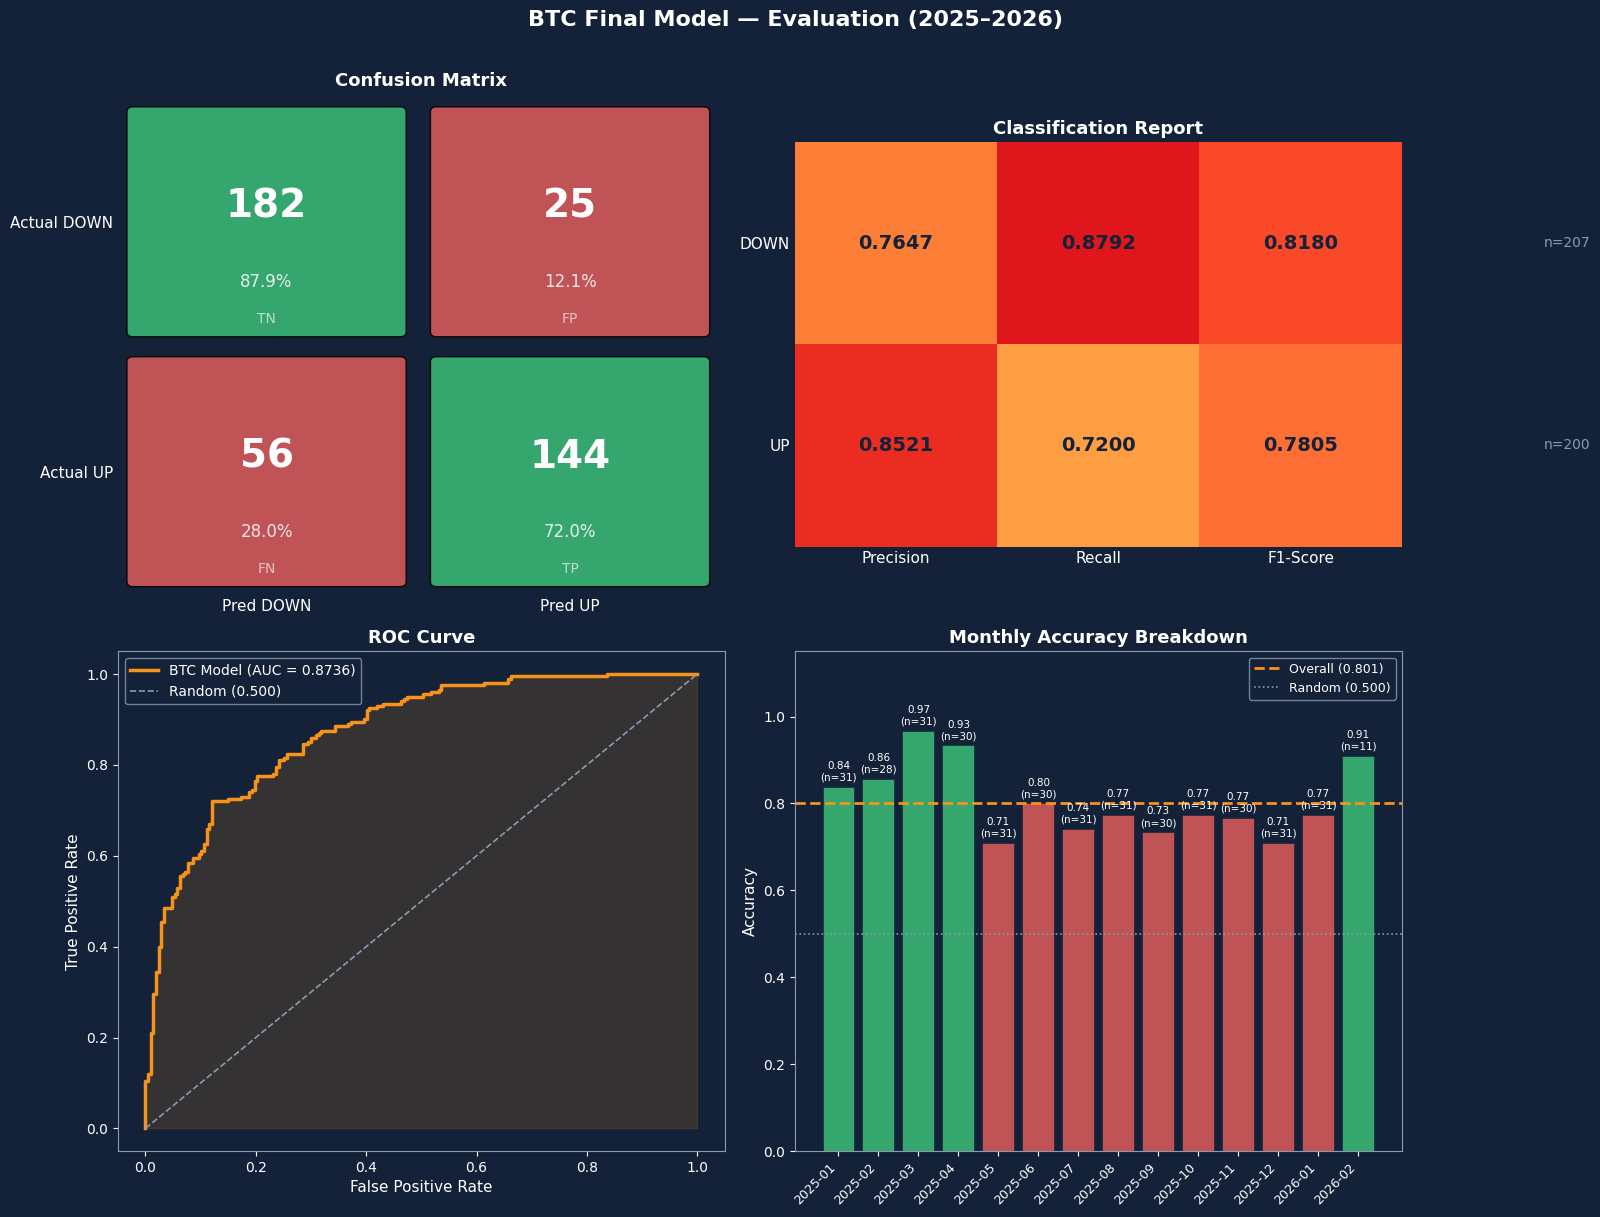

In [26]:
# ── 4 charts in one figure
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(NAVY)

# ════════════════════════════════
# CHART 1 — Confusion Matrix
# ════════════════════════════════
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor(NAVY)

labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val   = cm_btc[i, j]
        pct   = val / cm_btc[i].sum() * 100
        color = GREEN if labels[i][j] in ["TN","TP"] else RED
        ax1.add_patch(FancyBboxPatch(
            (j+0.05, 1-i+0.05), 0.88, 0.88,
            boxstyle="round,pad=0.02",
            facecolor=color, alpha=0.85
        ))
        ax1.text(j+0.49, 1-i+0.55, str(val),
                 ha="center", va="center",
                 fontsize=28, fontweight="bold", color=WHITE)
        ax1.text(j+0.49, 1-i+0.25, f"{pct:.1f}%",
                 ha="center", va="center",
                 fontsize=12, color=WHITE, alpha=0.85)
        ax1.text(j+0.49, 1-i+0.10, labels[i][j],
                 ha="center", va="center",
                 fontsize=10, color=WHITE, alpha=0.65)

ax1.set_xlim(0, 2); ax1.set_ylim(0, 2)
ax1.set_xticks([0.49, 1.49])
ax1.set_xticklabels(["Pred DOWN", "Pred UP"], color=WHITE, fontsize=11)
ax1.set_yticks([0.49, 1.49])
ax1.set_yticklabels(["Actual UP", "Actual DOWN"], color=WHITE, fontsize=11)
ax1.tick_params(colors=WHITE, length=0)
for spine in ax1.spines.values(): spine.set_visible(False)
ax1.set_title("Confusion Matrix", color=WHITE,
              fontsize=13, fontweight="bold")

# ════════════════════════════════
# CHART 2 — Classification Report
# ════════════════════════════════
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor(NAVY)

metrics = ["precision", "recall", "f1-score"]
classes = ["DOWN", "UP"]
data_cr = np.array([[cr_btc[c][m] for m in metrics] for c in classes])

im = ax2.imshow(data_cr, cmap="YlOrRd", vmin=0.5, vmax=1.0)
for i in range(len(classes)):
    for j in range(len(metrics)):
        ax2.text(j, i, f"{data_cr[i,j]:.4f}",
                 ha="center", va="center",
                 color=NAVY, fontsize=14, fontweight="bold")

ax2.set_xticks(range(len(metrics)))
ax2.set_xticklabels(["Precision", "Recall", "F1-Score"],
                     color=WHITE, fontsize=11)
ax2.set_yticks(range(len(classes)))
ax2.set_yticklabels(classes, color=WHITE, fontsize=11)
ax2.tick_params(colors=WHITE, length=0)
for spine in ax2.spines.values(): spine.set_visible(False)
ax2.set_title("Classification Report", color=WHITE,
              fontsize=13, fontweight="bold")

for i, c in enumerate(classes):
    ax2.text(3.2, i, f"n={cr_btc[c]['support']:.0f}",
             va="center", color=MUTED, fontsize=10)

# ════════════════════════════════
# CHART 3 — ROC Curve
# ════════════════════════════════
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_facecolor(NAVY)

fpr, tpr, _ = roc_curve(y_te_arr_btc, te_probas_btc)
auc_val = roc_auc_score(y_te_arr_btc, te_probas_btc)

ax3.plot(fpr, tpr, color=ORANGE, linewidth=2.5,
         label=f"BTC Model (AUC = {auc_val:.4f})")
ax3.fill_between(fpr, tpr, alpha=0.15, color=ORANGE)
ax3.plot([0,1], [0,1], color=MUTED, linewidth=1.2,
         linestyle="--", label="Random (0.500)")
ax3.set_xlabel("False Positive Rate", color=WHITE, fontsize=11)
ax3.set_ylabel("True Positive Rate", color=WHITE, fontsize=11)
ax3.set_title("ROC Curve", color=WHITE,
              fontsize=13, fontweight="bold")
ax3.tick_params(colors=WHITE)
for spine in ax3.spines.values(): spine.set_color(MUTED)
ax3.legend(facecolor=NAVY, edgecolor=MUTED,
           labelcolor=WHITE, fontsize=10)

# ════════════════════════════════
# CHART 4 — Monthly Accuracy
# ════════════════════════════════
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor(NAVY)

test_df_btc = s2_test_lag.copy()
test_df_btc["predicted"] = te_preds_btc
test_df_btc["correct"]   = (te_preds_btc == y_te_arr_btc).astype(int)
test_df_btc["month"]     = test_df_btc["timestamp"].dt.to_period("M")

monthly_btc = test_df_btc.groupby("month").agg(
    accuracy=("correct", "mean"),
    n_days  =("correct", "count")
).reset_index()
monthly_btc["month_str"] = monthly_btc["month"].astype(str)

bar_colors = [GREEN if a >= overall_acc else RED
              for a in monthly_btc["accuracy"]]

ax4.bar(range(len(monthly_btc)), monthly_btc["accuracy"],
        color=bar_colors, alpha=0.85,
        edgecolor=NAVY, linewidth=0.5)
ax4.axhline(overall_acc, color=ORANGE, linewidth=2,
            linestyle="--",
            label=f"Overall ({overall_acc:.3f})")
ax4.axhline(0.5, color=MUTED, linewidth=1.2,
            linestyle=":", label="Random (0.500)")

for i, (acc, n) in enumerate(
        zip(monthly_btc["accuracy"], monthly_btc["n_days"])):
    ax4.text(i, acc + 0.01, f"{acc:.2f}\n(n={n})",
             ha="center", va="bottom",
             color=WHITE, fontsize=7.5)

ax4.set_xticks(range(len(monthly_btc)))
ax4.set_xticklabels(monthly_btc["month_str"],
                     rotation=45, ha="right",
                     color=WHITE, fontsize=9)
ax4.set_ylabel("Accuracy", color=WHITE, fontsize=11)
ax4.set_ylim(0, 1.15)
ax4.set_title("Monthly Accuracy Breakdown",
              color=WHITE, fontsize=13, fontweight="bold")
ax4.tick_params(colors=WHITE)
for spine in ax4.spines.values(): spine.set_color(MUTED)
ax4.legend(facecolor=NAVY, edgecolor=MUTED,
           labelcolor=WHITE, fontsize=9)

plt.suptitle("BTC Final Model — Evaluation (2025–2026)",
             color=WHITE, fontsize=16,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("btc_evaluation.png", dpi=150,
            bbox_inches="tight", facecolor=NAVY)
plt.show()

In [27]:
# ── Print insights
best_month_btc  = monthly_btc.loc[monthly_btc["accuracy"].idxmax()]
worst_month_btc = monthly_btc.loc[monthly_btc["accuracy"].idxmin()]
above_avg_btc   = (monthly_btc["accuracy"] >= overall_acc).sum()

print("="*60)
print("  BTC FINAL MODEL — EVALUATION SUMMARY")
print("="*60)
print(f"""
── CORE METRICS ──
  Test Accuracy : {overall_acc*100:.2f}%
  Test MCC      : 0.6079
  Test AUC      : {auc_val:.4f}

── CONFUSION MATRIX ──
  DOWN recall : {down_recall:.1f}% ({tn}/{tn+fp} correct)
  UP recall   : {up_recall:.1f}%  ({tp}/{tp+fn} correct)

── CLASSIFICATION ──
  DOWN — Precision: {cr_btc['DOWN']['precision']:.4f} | Recall: {cr_btc['DOWN']['recall']:.4f} | F1: {cr_btc['DOWN']['f1-score']:.4f}
  UP   — Precision: {cr_btc['UP']['precision']:.4f} | Recall: {cr_btc['UP']['recall']:.4f} | F1: {cr_btc['UP']['f1-score']:.4f}
  Macro F1 : {cr_btc['macro avg']['f1-score']:.4f}

── MONTHLY STABILITY ──
  Best month       : {best_month_btc['month_str']} ({best_month_btc['accuracy']*100:.1f}%)
  Worst month      : {worst_month_btc['month_str']} ({worst_month_btc['accuracy']*100:.1f}%)
  Months above avg : {above_avg_btc}/{len(monthly_btc)}
""")

from google.colab import files
files.download("btc_evaluation.png")

  BTC FINAL MODEL — EVALUATION SUMMARY

── CORE METRICS ──
  Test Accuracy : 80.10%
  Test MCC      : 0.6079
  Test AUC      : 0.8736

── CONFUSION MATRIX ──
  DOWN recall : 87.9% (182/207 correct)
  UP recall   : 72.0%  (144/200 correct)

── CLASSIFICATION ──
  DOWN — Precision: 0.7647 | Recall: 0.8792 | F1: 0.8180
  UP   — Precision: 0.8521 | Recall: 0.7200 | F1: 0.7805
  Macro F1 : 0.7992

── MONTHLY STABILITY ──
  Best month       : 2025-03 (96.8%)
  Worst month      : 2025-05 (71.0%)
  Months above avg : 5/14



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Insight: An MCC of 0.608 on a balanced binary financial problem is a strong result it means the model is capturing genuine market structure, not noise. AUC of 0.874 confirms the probability scores are well-ordered and usable for confidence thresholding.

Insight: The model has a clear directional asymmetry  it detects DOWN days more reliably (87.9% recall) but is more precise when calling UP (85.2% precision). In practical terms: when the model says UP, it's right 85% of the time a high confidence signal. When the market drops, the model rarely misses it (only 25 missed DOWN days out of 207). The trade-off is 56 false UP predictions days predicted up that went down.
Strategic implication: The model is better suited to avoid false confidence on UP signals than to catch every up move. Precision-oriented use case.

Insight: Only 5/14 months beat the average, meaning performance is right-skewed a few very strong months pull the average up, while the majority cluster slightly below. The 25.8pp spread between best and worst month is significant. This points to regime sensitivity: the model performs differently depending on market conditions (trending vs choppy). The 71% floor in May 2025 is still well above random, confirming robustness even in its worst period.

9. Ensemble test

In [30]:
# ══════════════════════════════════════════════════════════════
# EXP 5B — ENSEMBLE COMPARISON — BTC (proof + curiosity)
# Goal : show GB individual beats ensemble on BTC too
# Benchmark : GB individual test MCC = 0.608
# ══════════════════════════════════════════════════════════════

from sklearn.ensemble     import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

def get_estimators_btc():
    return [
        ("rf",  RandomForestClassifier(
                    **BEST_RF, random_state=42, n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(
                    **BEST_GB, random_state=42)),
        ("xgb", xgb.XGBClassifier(
                    **BEST_XGB, random_state=42,
                    eval_metric="logloss", verbosity=0))
    ]

print("="*60)
print("  EXP 5B — ENSEMBLE COMPARISON — BTC")
print("="*60)

# ── Soft Voting
soft_btc = evaluate(
    VotingClassifier(estimators=get_estimators_btc(), voting="soft"),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "Soft Voting — BTC"
)

# ── Hard Voting
hard_btc = evaluate(
    VotingClassifier(estimators=get_estimators_btc(), voting="hard"),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "Hard Voting — BTC"
)

# ── Stacking
stacking_btc = evaluate(
    StackingClassifier(
        estimators=get_estimators_btc(),
        final_estimator=LogisticRegression(random_state=42),
        cv=5,
        stack_method="predict_proba"
    ),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "Stacking (RF+GB+XGB → LR) — BTC"
)

# ── GB individual reference
gb_indiv_btc = evaluate(
    GradientBoostingClassifier(**BEST_GB, random_state=42),
    X_tr, y_tr, X_vl, y_vl, X_te, y_te,
    "GB Individual — BTC"
)

print("\n── EXP 5B SUMMARY — ENSEMBLE vs GB INDIVIDUAL BTC ──")
compare([gb_indiv_btc, soft_btc, hard_btc, stacking_btc])

print("\n── VERDICT ──")
best_ensemble_mcc = max(
    soft_btc["test_mcc"],
    stacking_btc["test_mcc"]
)
if gb_indiv_btc["test_mcc"] > best_ensemble_mcc:
    print(f"  ✅ GB Individual wins — MCC {gb_indiv_btc['test_mcc']:.4f}")
    print(f"     Best ensemble MCC  : {best_ensemble_mcc:.4f}")
    print(f"     Gain over ensemble : +{gb_indiv_btc['test_mcc'] - best_ensemble_mcc:.4f}")
    print(f"     Decision → GB Individual confirmed as final BTC model")
else:
    print(f"  ⚠️  Ensemble wins — MCC {best_ensemble_mcc:.4f}")
    print(f"     GB Individual MCC  : {gb_indiv_btc['test_mcc']:.4f}")


  EXP 5B — ENSEMBLE COMPARISON — BTC

  Soft Voting — BTC
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7332   0.4669    0.7838    0.5719    0.8671   0.08    ✅


  Hard Voting — BTC
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   0.4646    0.7862    0.5765       N/A   0.08    ✅


  Stacking (RF+GB+XGB → LR) — BTC
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7415   0.4827    0.7764    0.5554    0.8799   0.07    ✅


  GB Individual — BTC
                        Val Acc  Val MCC  Test Acc  Test MCC  Test AUC    Gap     
  ----------------------------------------------------------
  Results                0.7319   0